# Phase 5 — Explainability

Opening the black box: which features drive the Random Forest, and in which direction?
Three complementary methods — **feature importance**, **SHAP**, **LIME** — applied to a Random Forest trained on all data.

*This is the project's main contribution relative to prior deep-learning work on EMIR.*

In [1]:
import numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier

# Anchor to project root: works whether run from repo root or notebooks/.
# Figures/features go to the SHARED root folders (same as the src/ scripts).
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
RAW  = ROOT / 'data' / 'raw'
FEAT = ROOT / 'features'; FEAT.mkdir(exist_ok=True)
FIG  = ROOT / 'figures';  FIG.mkdir(exist_ok=True)
X = np.load(FEAT/'X.npy'); y = np.load(FEAT/'y.npy', allow_pickle=True)
names  = [f'mfcc{i}_mean' for i in range(20)] + [f'mfcc{i}_std' for i in range(20)]
names += [f'chroma{i}_mean' for i in range(12)] + [f'chroma{i}_std' for i in range(12)]
names = np.array(names)
rf = RandomForestClassifier(n_estimators=200, random_state=42).fit(X, y)

## 5.1  Built-in feature importance
How much each feature reduced impurity across all 200 trees. We also check the **MFCC vs chroma** split.

In [2]:
imp = rf.feature_importances_
order = np.argsort(imp)[::-1]
print('Top 15 features:')
for i in order[:15]:
    print(f'  {names[i]:15s} {imp[i]:.4f}')
mfcc_mask = np.char.startswith(names.astype(str), 'mfcc')
chroma_mask = np.char.startswith(names.astype(str), 'chroma')
print('\nTotal importance  MFCC: %.3f | chroma: %.3f' % (imp[mfcc_mask].sum(), imp[chroma_mask].sum()))

Top 15 features:
  mfcc0_std       0.0929
  chroma0_mean    0.0271
  chroma9_std     0.0237
  chroma5_std     0.0234
  mfcc4_std       0.0230
  chroma5_mean    0.0225
  mfcc7_mean      0.0225
  mfcc3_std       0.0219
  chroma4_mean    0.0203
  chroma9_mean    0.0201
  mfcc14_std      0.0193
  mfcc1_std       0.0187
  mfcc6_std       0.0179
  chroma11_std    0.0177
  mfcc6_mean      0.0173

Total importance  MFCC: 0.619 | chroma: 0.381


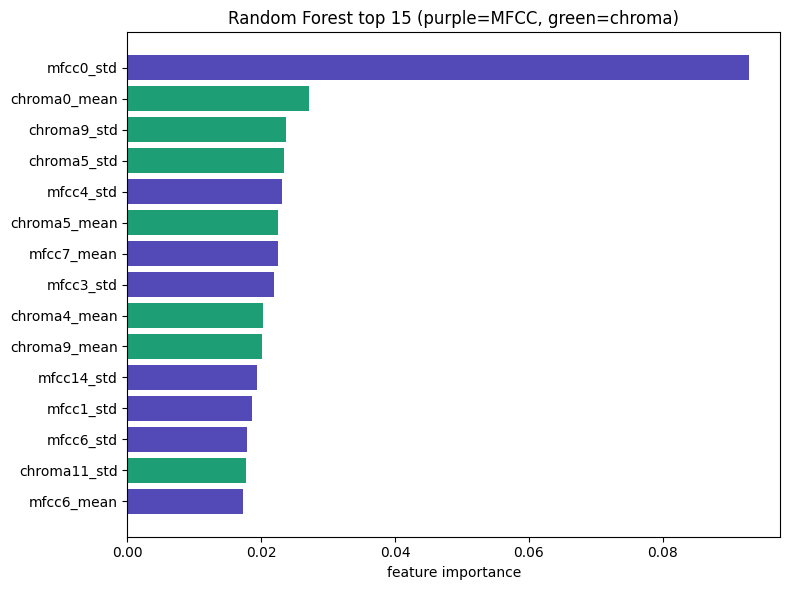

In [3]:
top = order[:15][::-1]
colors = ['#534AB7' if names[i].startswith('mfcc') else '#1D9E75' for i in top]
plt.figure(figsize=(8,6))
plt.barh(range(len(top)), imp[top], color=colors)
plt.yticks(range(len(top)), names[top])
plt.xlabel('feature importance'); plt.title('Random Forest top 15 (purple=MFCC, green=chroma)')
plt.tight_layout(); plt.savefig(FIG/'feature_importance.png', dpi=150); plt.show()

In [5]:
pip install shap lime

  Using cached shap-0.52.0-cp312-abi3-macosx_11_0_arm64.whl.metadata (26 kB)
  Using cached lime-0.2.0.1-py3-none-any.whl
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached scikit_image-0.26.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (15 kB)
  Using cached imageio-2.37.3-py3-none-any.whl.metadata (9.7 kB)
  Using cached tifffile-2026.6.1-py3-none-any.whl.metadata (33 kB)
Using cached shap-0.52.0-cp312-abi3-macosx_11_0_arm64.whl (490 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached scikit_image-0.26.0-cp313-cp313-macosx_11_0_arm64.whl (12.0 MB)
Using cached imageio-2.37.3-py3-none-any.whl (317 kB)
Using cached tifffile-2026.6.1-py3-none-any.whl (267 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [lime]5/7 [shap]t-image]

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip ins

## 5.2  SHAP
SHAP shows not just which features matter but **how** their values push predictions toward Tizita or Bati.
Requires `pip install shap`.

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


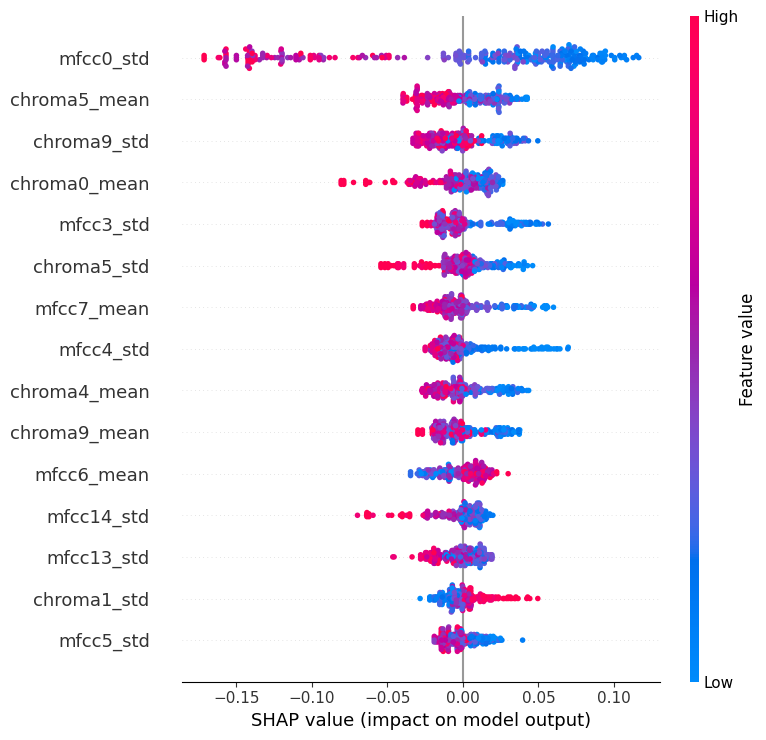

In [6]:
import shap
explainer = shap.TreeExplainer(rf)
sv = explainer.shap_values(X)
classes = list(rf.classes_)
# select the 'tizita' class values (handles list or 3-D array across shap versions)
tz = classes.index('tizita')
vals = sv[tz] if isinstance(sv, list) else sv[:, :, tz]
shap.summary_plot(vals, X, feature_names=list(names), max_display=15, show=False)
plt.tight_layout(); plt.savefig(FIG/'shap_summary.png', dpi=150, bbox_inches='tight'); plt.show()

## 5.3  LIME
LIME explains a **single** prediction by fitting a simple local model around it. Requires `pip install lime`.
Note: LIME has sampling randomness, so exact weights vary slightly between runs.

Explaining clip 144 | true = tizita
  mfcc0_std > 64.95              -0.1179
  mfcc15_mean > 0.00             +0.0271
  chroma4_mean <= 0.31           +0.0230
  chroma1_std > 0.32             +0.0195
  mfcc6_std > 11.14              -0.0194
  mfcc4_std > 13.74              -0.0185
  chroma5_mean <= 0.31           +0.0156
  mfcc1_std > 24.96              -0.0153
  mfcc14_std <= 7.15             +0.0133
  11.14 < mfcc5_std <= 13.13     -0.0116


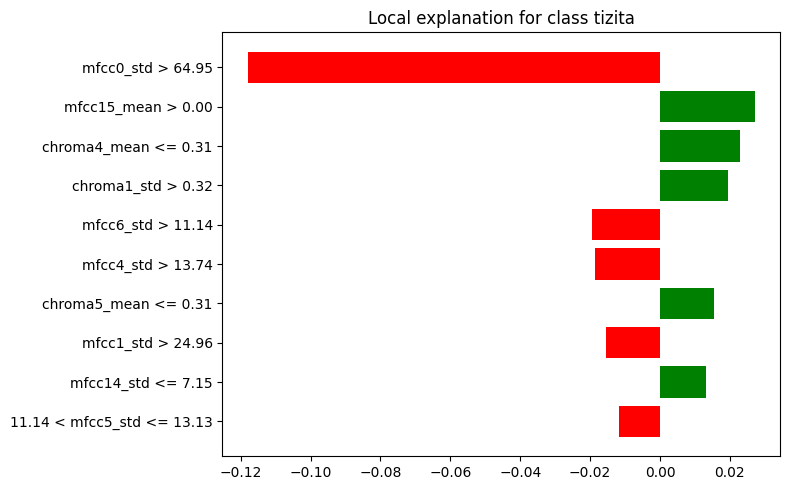

In [7]:
from lime.lime_tabular import LimeTabularExplainer
explainer = LimeTabularExplainer(X, feature_names=list(names), class_names=classes,
                                 discretize_continuous=True, mode='classification')
idx = int(np.where(y=='tizita')[0][0])   # explain one Tizita clip
exp = explainer.explain_instance(X[idx], rf.predict_proba, num_features=10)
print('Explaining clip', idx, '| true =', y[idx])
for feat, w in exp.as_list():
    print(f'  {feat:30s} {w:+.4f}')
fig = exp.as_pyplot_figure(); fig.set_size_inches(8,5); fig.tight_layout()
fig.savefig(FIG/'lime_example.png', dpi=150, bbox_inches='tight'); plt.show()

**Result.** The three methods converge: energy variability (`mfcc0_std`) is the strongest cue (high → Bati), while several chroma features systematically distinguish the scales — evidence the model uses genuine pitch-class content alongside timbral cues. The prominence of an energy feature is flagged as a possible link to recording/performance style.

---
End of pipeline. See the report and README for the full write-up.